In [9]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/PedroSilvazDev/trabalho-final-ia-diabetes-colab.git"
REPO_DIR = "trabalho-final-ia-diabetes-colab"

if Path("src").exists():
    root = Path.cwd()
elif Path(REPO_DIR, "src").exists():
    os.chdir(REPO_DIR)
    root = Path.cwd()
else:
    !git clone {REPO_URL}
    os.chdir(REPO_DIR)
    root = Path.cwd()

sys.path.insert(0, str(root))
!pip install -q -r requirements.txt

print("Diretorio:", root)

Diretorio: /content/trabalho-final-ia-diabetes-colab


## 1. Carregar dataset

| Item | Descrição |
|------|-----------|
| Nome | Pima Indians Diabetes Database |
| Origem | Kaggle / UCI ML Repository |
| Registros | 768 amostras |
| Variável alvo | Outcome (0 = sem diabetes, 1 = com diabetes) |

In [10]:
import pandas as pd
from IPython.display import display

from src.data_loader import load_dataset

df = load_dataset()
print(f"Registros: {len(df)} | Atributos: {df.shape[1] - 1}")
print("\nDistribuicao da variavel alvo:")
print(df["Outcome"].value_counts())
display(df.head())

Registros: 768 | Atributos: 8

Distribuicao da variavel alvo:
Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Preparação dos dados

**Limpeza comum:** zeros inválidos viram ausentes + divisão estratificada 80/20.

**Pipeline fixo por modelo** (melhor configuração já definida em `config.py`):

- **KNN:** mediana + StandardScaler, k=13, uniform, euclidiana
- **SVM:** média + StandardScaler, kernel RBF, C=1, class_weight=balanced

In [11]:
from src.preprocess import split_data

split = split_data(df)
print(f"Treino: {len(split.y_train)} amostras")
print(f"Teste: {len(split.y_test)} amostras")
print("\nCada modelo usa o pipeline otimizado fixo definido em config.py.")

Treino: 614 amostras
Teste: 154 amostras

Cada modelo usa o pipeline otimizado fixo definido em config.py.


## 3. Treinamento - KNN (Parte 1)

In [12]:
from src.train import train_knn, print_result_summary

knn_result = train_knn(split)
print_result_summary(knn_result, split)


=== KNN ===
Pre-processamento: KNN: imputacao mediana, StandardScaler, k=13, weights=uniform, metric=euclidean
Melhores hiperparametros: {'imputer__strategy': 'median', 'knn__metric': 'euclidean', 'knn__n_neighbors': 13, 'knn__weights': 'uniform', 'scaler': StandardScaler()}
Acuracia no treino: 0.8062
Acuracia no teste: 0.7143
Precisao: 0.6087
Revocacao: 0.5185
F1-score: 0.5600
ROC-AUC: 0.7944


## 4. Treinamento - SVM (Parte 2)

In [13]:
from src.train import train_svm

svm_result = train_svm(split)
print_result_summary(svm_result, split)


=== SVM ===
Pre-processamento: SVM: imputacao mean, StandardScaler, kernel=rbf, C=1, gamma=scale, class_weight=balanced
Melhores hiperparametros: {'imputer__strategy': 'mean', 'scaler': StandardScaler(), 'svm__C': 1, 'svm__class_weight': 'balanced', 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Acuracia no treino: 0.8225
Acuracia no teste: 0.7338
Precisao: 0.5970
Revocacao: 0.7407
F1-score: 0.6612
ROC-AUC: 0.8170


## 5. Avaliação e comparação

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

from src.evaluate import (
    plot_confusion_matrix,
    plot_metrics_comparison,
    plot_roc_curves,
)

%matplotlib inline

metrics_df = pd.DataFrame([
    {"modelo": "KNN", **knn_result.metrics},
    {"modelo": "SVM", **svm_result.metrics},
])

display(metrics_df)

,modelo,accuracy,precision,recall,f1_score,roc_auc
0,KNN,0.714286,0.608696,0.518519,0.560000,0.794444
1,SVM,0.733766,0.597015,0.740741,0.661157,0.817037


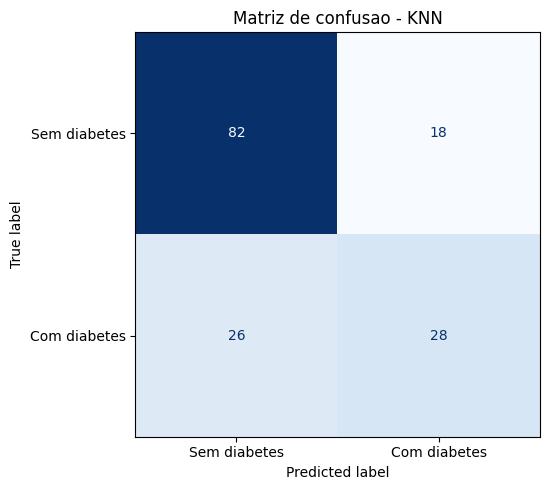

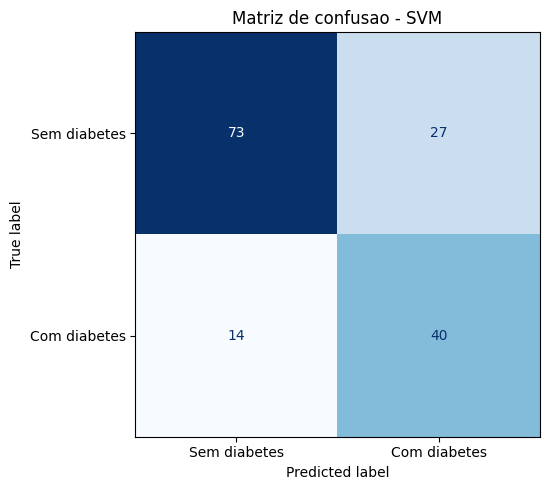

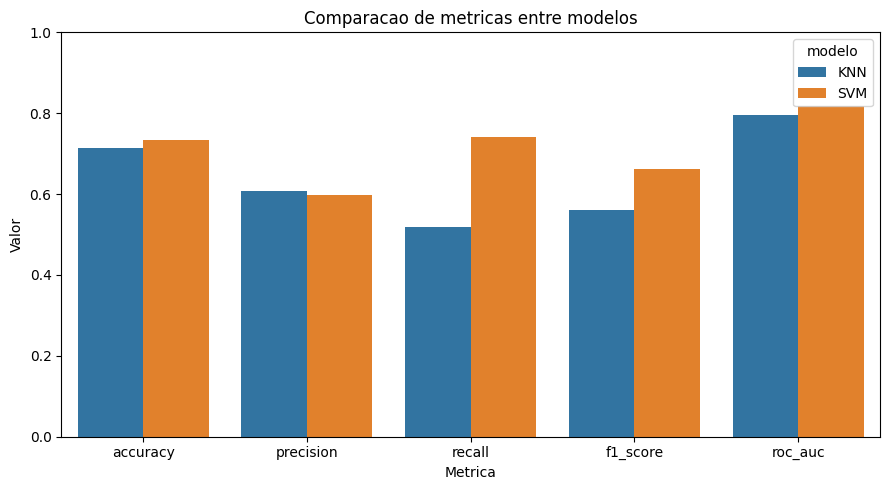

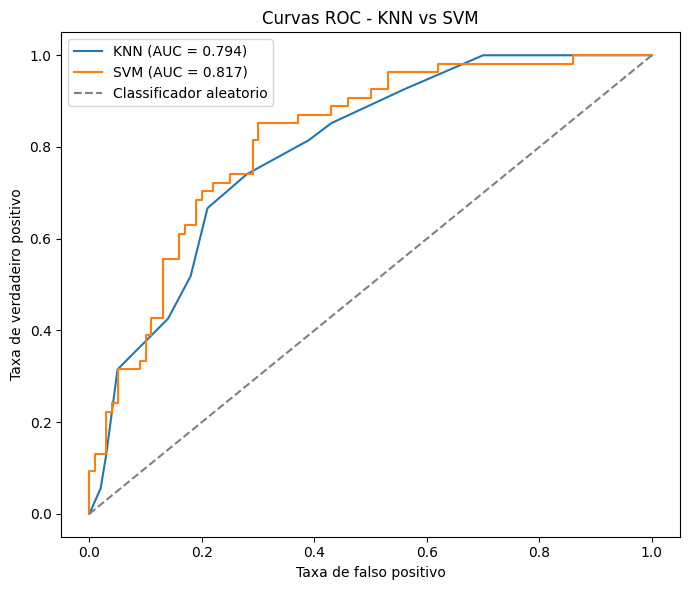

In [15]:
plot_confusion_matrix(split.y_test, knn_result.y_pred, "KNN")
plot_confusion_matrix(split.y_test, svm_result.y_pred, "SVM")
plot_metrics_comparison(metrics_df)
plot_roc_curves([
    {
        "model_name": "KNN",
        "y_true": split.y_test,
        "y_proba": knn_result.y_proba,
        "metrics": knn_result.metrics,
    },
    {
        "model_name": "SVM",
        "y_true": split.y_test,
        "y_proba": svm_result.y_proba,
        "metrics": svm_result.metrics,
    },
])

## 6. Comparação dos resultados

O modelo com melhor desempenho geral foi o **SVM**, com F1-score de 0,66, acurácia de 73,4% e ROC-AUC de 0,82. O pré-processamento dedicado (imputação pela média, `class_weight=balanced`, kernel RBF) melhorou a revocação para 74,1%.

- **KNN:** mediana + StandardScaler, k=13, uniform, euclidiana — F1=0,56
- **SVM:** média + StandardScaler, kernel RBF, C=1, class_weight=balanced — F1=0,66

## Conclusão

Cada algoritmo se beneficia de um pipeline diferente. O SVM superou o KNN após otimização específica, demonstrando que o pré-processamento deve ser adaptado ao modelo, não aplicado de forma idêntica a todos.